# 🚀 Boosting Classifiers — AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost

The final Classification topic, and the most powerful ensemble idea in this series. Random Forest trains many trees **independently** and averages them (parallel). Boosting trains trees **sequentially**, where each new tree specifically targets the previous ensemble's mistakes — a fundamentally different way of combining weak learners into a strong one.

📖 Full mathematical explanation (AdaBoost's weight updates, gradient boosting's functional gradient descent, XGBoost's regularized objective): [README.md](README.md)


## 1. Setup & Dataset


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
import lightgbm as lgb
import catboost as cb


In [2]:
sns.set_theme(style="whitegrid")
np.random.seed(42)


In [3]:
X_2d, y_2d = make_classification(
    n_samples=200, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.0, flip_y=0.05, random_state=42
)


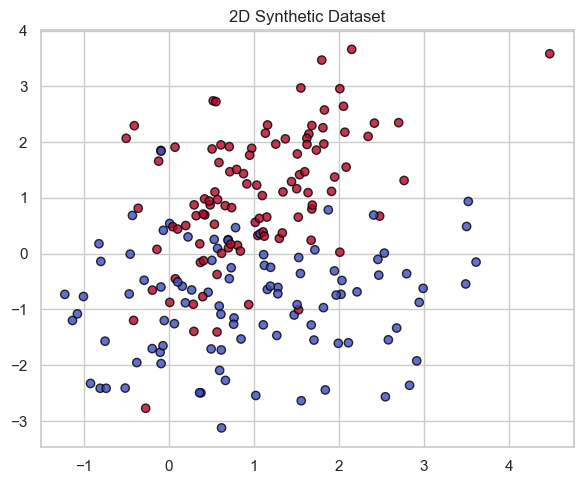

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black", alpha=0.8)
ax.set_title("2D Synthetic Dataset")
plt.tight_layout()
plt.show()


## 2. Bagging vs Boosting — the Core Conceptual Split

Random Forest's trees are trained **independently and in parallel** on random resamples, then averaged (reduces variance). Boosting trains trees **sequentially**, each one explicitly correcting the errors of everything trained before it (reduces bias). Neither is strictly better — they solve different problems.


In [5]:
comparison = pd.DataFrame({
    "Aspect": ["Training order", "What each tree sees", "Primarily reduces", "Overfitting risk", "Typical tree depth"],
    "Bagging (Random Forest)": ["Parallel, independent", "A random bootstrap resample", "Variance", "Lower", "Deep (fully grown)"],
    "Boosting": ["Sequential, dependent", "Previous ensemble's errors/residuals", "Bias", "Higher (needs tuning)", "Shallow (\"weak learners\", stumps to depth 3-6)"],
})
comparison


,Aspect,Bagging (Random Forest),Boosting
0,Training order,"Parallel, independent","Sequential, dependent"
1,What each tree sees,A random bootstrap resample,Previous ensemble's errors/residuals
2,Primarily reduces,Variance,Bias
3,Overfitting risk,Lower,Higher (needs tuning)
4,Typical tree depth,Deep (fully grown),"Shallow (""weak learners"", stumps to depth 3-6)"


## 3. AdaBoost — Reweighting Misclassified Points

AdaBoost (Adaptive Boosting) trains a sequence of **weak learners** (often decision stumps — depth-1 trees). After each one, misclassified points get **higher weight**, so the next weak learner is forced to focus on exactly what the ensemble got wrong so far. Formula for weight updates in the README.


In [6]:
def train_adaboost_scratch(X, y, n_estimators=10):
    n = len(X)
    sample_weights = np.full(n, 1 / n)   # start: every point weighted equally
    y_signed = np.where(y == 0, -1, 1)   # AdaBoost's math uses +1/-1 labels, not 0/1
    stumps, alphas = [], []
    for t in range(n_estimators):
        stump = DecisionTreeClassifier(max_depth=1)
        stump.fit(X, y, sample_weight=sample_weights)
        preds = np.where(stump.predict(X) == 0, -1, 1)
        incorrect = (preds != y_signed)
        error = np.sum(sample_weights * incorrect) / np.sum(sample_weights)
        error = np.clip(error, 1e-10, 1 - 1e-10)   # avoid log(0)/div-by-0 at the extremes
        alpha = 0.5 * np.log((1 - error) / error)   # this weak learner's voting weight
        sample_weights *= np.exp(-alpha * y_signed * preds)   # up-weight mistakes, down-weight correct
        sample_weights /= sample_weights.sum()   # renormalize to a valid distribution
        stumps.append(stump)
        alphas.append(alpha)
    return stumps, alphas


In [7]:
def predict_adaboost_scratch(stumps, alphas, X):
    weighted_votes = sum(a * np.where(s.predict(X) == 0, -1, 1) for s, a in zip(stumps, alphas))
    return (weighted_votes > 0).astype(int)


In [8]:
stumps, alphas = train_adaboost_scratch(X_2d, y_2d, n_estimators=20)
scratch_preds = predict_adaboost_scratch(stumps, alphas, X_2d)
print("From-scratch AdaBoost (20 stumps) training accuracy:", round(accuracy_score(y_2d, scratch_preds), 4))
print("Alpha (voting weight) per stump:", np.round(alphas[:5], 3), "...")


From-scratch AdaBoost (20 stumps) training accuracy: 0.865
Alpha (voting weight) per stump: [0.829 0.348 0.363 0.187 0.261] ...


## 4. Comparing Against scikit-learn's AdaBoostClassifier


In [9]:
sklearn_ada = AdaBoostClassifier(n_estimators=20, random_state=42)
sklearn_ada.fit(X_2d, y_2d)


,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](20,)","[0.16,0.33,0.33,...,0.4 ,0.44,0.45]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](20,)","[1.66,0.7 ,0.73,...,0.4 ,0.25,0.2 ]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](2,)","[0.41,0.59]"


In [10]:
print(f"From-scratch accuracy: {accuracy_score(y_2d, scratch_preds):.4f}")
print(f"sklearn accuracy:      {accuracy_score(y_2d, sklearn_ada.predict(X_2d)):.4f}")


From-scratch accuracy: 0.8650
sklearn accuracy:      0.8650


## 5. Visualizing How the Boundary Sharpens with More Weak Learners

A single decision stump can only split on one feature once — barely better than random. Watching the ensemble's boundary refine as more stumps are added makes AdaBoost's "weak learners combining into a strong one" concrete.


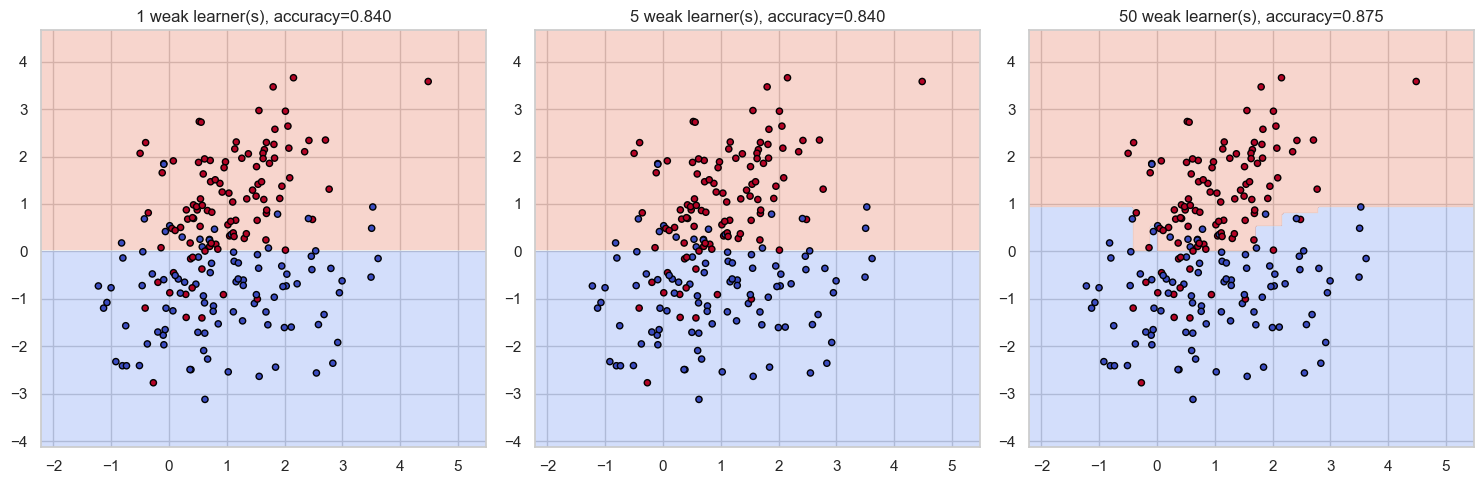

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, n_est in zip(axes, [1, 5, 50]):
    model = AdaBoostClassifier(n_estimators=n_est, random_state=42).fit(X_2d, y_2d)
    x_range = np.linspace(X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1, 200)
    y_range = np.linspace(X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1, 200)
    xx, yy = np.meshgrid(x_range, y_range)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=2, cmap="coolwarm", alpha=0.3)
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black", s=20)
    acc = accuracy_score(y_2d, model.predict(X_2d))
    ax.set_title(f"{n_est} weak learner(s), accuracy={acc:.3f}")
plt.tight_layout()
plt.show()


## 6. Gradient Boosting — Fitting to the Residuals

Gradient Boosting takes a different sequential strategy: instead of reweighting samples, each new tree is trained to predict the **residual error** (or more precisely, the negative gradient of the loss) of the current ensemble. For squared-error regression, this residual is literally `actual - predicted`; for classification's log loss, it generalizes to a gradient. Formula in the README.


In [12]:
# Illustrate the core idea on a regression-style residual-fitting loop (the mechanism generalizes to classification)
x_toy = np.linspace(0, 10, 50).reshape(-1, 1)
y_toy = np.sin(x_toy).ravel() + np.random.normal(0, 0.1, 50)


In [13]:
prediction = np.zeros(len(y_toy))   # start: predict 0 for everyone
learning_rate = 0.5
residual_history = []


In [14]:
for round_num in range(5):
    residual = y_toy - prediction   # what's still unexplained by the ensemble so far
    residual_history.append(residual.copy())
    stump = DecisionTreeRegressor(max_depth=2)
    stump.fit(x_toy, residual)
    prediction += learning_rate * stump.predict(x_toy)   # each new tree nudges the prediction toward the residual


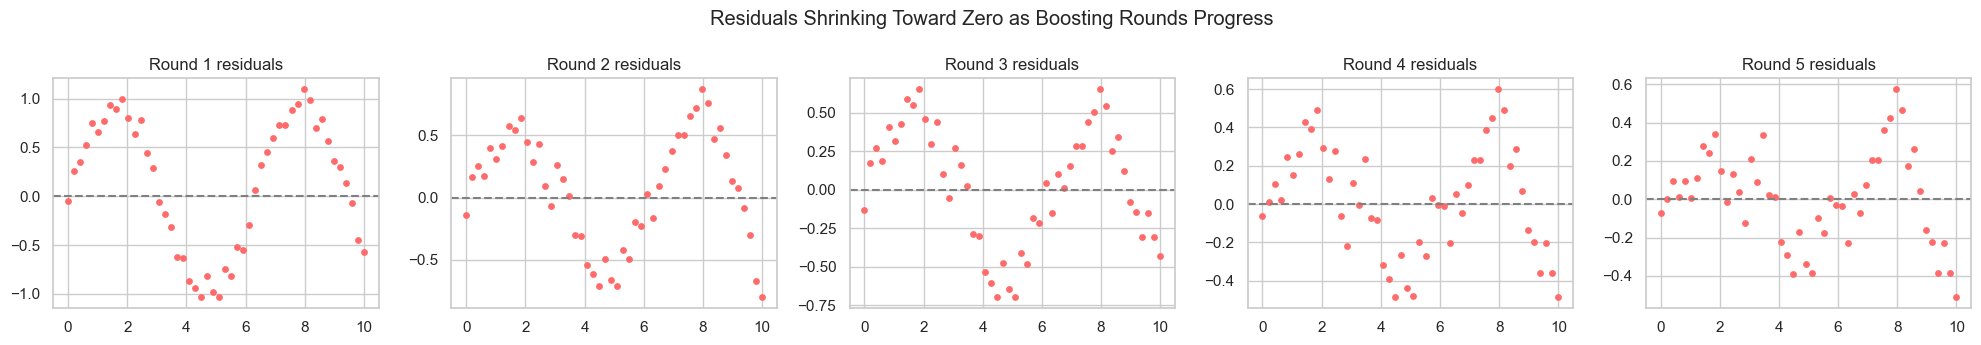

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for i, (ax, res) in enumerate(zip(axes, residual_history)):
    ax.scatter(x_toy, res, s=15, color="#ff6b6b")
    ax.axhline(0, color="gray", linestyle="--")
    ax.set_title(f"Round {i+1} residuals")
plt.suptitle("Residuals Shrinking Toward Zero as Boosting Rounds Progress")
plt.tight_layout()
plt.show()


## 7. Gradient Boosting on the Classification Task

`GradientBoostingClassifier` applies the same residual-fitting idea using log loss's gradient instead of squared-error residuals directly.


In [16]:
gb_model = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_2d, y_2d)
print(f"Gradient Boosting training accuracy: {accuracy_score(y_2d, gb_model.predict(X_2d)):.4f}")


Gradient Boosting training accuracy: 0.9450


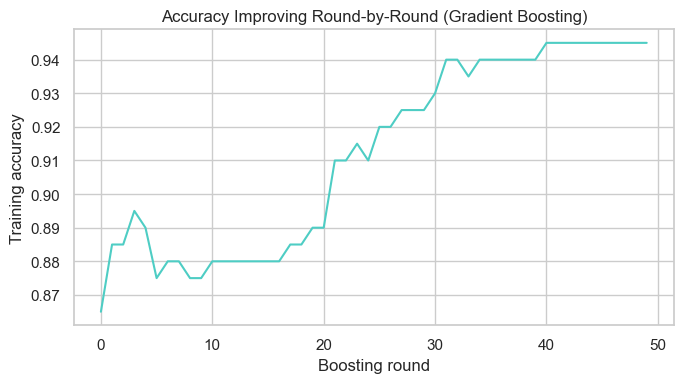

In [17]:
# staged_predict lets us see accuracy improve round-by-round, directly observing the sequential correction process
staged_accuracies = [accuracy_score(y_2d, preds) for preds in gb_model.staged_predict(X_2d)]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(staged_accuracies, color="#4ecdc4")
ax.set_xlabel("Boosting round"); ax.set_ylabel("Training accuracy")
ax.set_title("Accuracy Improving Round-by-Round (Gradient Boosting)")
plt.tight_layout()
plt.show()


## 8. Learning Rate — the Shrinkage Parameter

`learning_rate` scales each new tree's contribution to the ensemble (same role as gradient descent's $\eta$ from the Math Refresher). Smaller learning rates need more trees to reach the same fit, but generalize better — a direct tradeoff between `n_estimators` and `learning_rate`.


In [18]:
cancer = load_breast_cancer(as_frame=True)
X_cancer, y_cancer = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, test_size=0.2, stratify=y_cancer, random_state=42)


In [19]:
for lr in [0.01, 0.1, 0.5, 1.0]:
    model = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, max_depth=3, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=5).mean()
    print(f"learning_rate={lr:4.2f} -> CV accuracy: {score:.4f}")


learning_rate=0.01 -> CV accuracy: 0.9451


learning_rate=0.10 -> CV accuracy: 0.9560


learning_rate=0.50 -> CV accuracy: 0.9648


learning_rate=1.00 -> CV accuracy: 0.9582


## 9. XGBoost — Regularized, Second-Order Gradient Boosting

XGBoost extends gradient boosting with an explicit regularization term (penalizing tree complexity directly in the objective, similar in spirit to Ridge/Lasso) and uses a second-order (Newton's method style) approximation of the loss for faster, more precise optimization.


In [20]:
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, eval_metric="logloss")
xgb_model.fit(X_train, y_train)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [21]:
xgb_preds = xgb_model.predict(X_test)
print(f"XGBoost test accuracy: {accuracy_score(y_test, xgb_preds):.4f}")


XGBoost test accuracy: 0.9474


## 10. LightGBM — Leaf-Wise Growth and Histogram Binning

LightGBM grows trees **leaf-wise** (always splitting whichever leaf reduces loss the most) rather than **level-wise** (splitting every leaf at the current depth, like standard sklearn trees) — often reaching a better fit with fewer splits. It also bins continuous features into histograms internally, trading a small amount of precision for a large speed gain on big datasets.


In [22]:
lgb_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)


,max_depth,3
,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [23]:
lgb_preds = lgb_model.predict(X_test)
print(f"LightGBM test accuracy: {accuracy_score(y_test, lgb_preds):.4f}")


LightGBM test accuracy: 0.9561


## 11. CatBoost — Ordered Boosting and Native Categorical Support

CatBoost's signature idea is **ordered boosting**: it avoids a subtle form of target leakage that standard gradient boosting can suffer (where a tree's own training data influences the residual it's trying to predict) by using a different, carefully-ordered subset of data for each step. It also handles categorical features natively, without requiring manual one-hot encoding.


In [24]:
cat_model = cb.CatBoostClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, verbose=0)
cat_model.fit(X_train, y_train)


CatBoostClassifier(learning_rate=0.1, max_depth=3, n_estimators=100, random_state=42, verbose=0)

In [25]:
cat_preds = cat_model.predict(X_test)
print(f"CatBoost test accuracy: {accuracy_score(y_test, cat_preds):.4f}")


CatBoost test accuracy: 0.9649


## 12. All Five Boosting Methods — Head-to-Head

Accuracy alone doesn't tell the whole story — training time matters in practice too, especially as datasets grow. Comparing all five on identical data and splits.


In [26]:
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
gb_final = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)


In [27]:
boosting_models = {
    "AdaBoost": ada_model,
    "Gradient Boosting": gb_final,
    "XGBoost": xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, eval_metric="logloss"),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, verbose=-1),
    "CatBoost": cb.CatBoostClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, verbose=0),
}


In [28]:
results = []
for name, model in boosting_models.items():
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start
    acc = accuracy_score(y_test, model.predict(X_test))
    results.append({"Model": name, "Test Accuracy": round(acc, 4), "Fit Time (s)": round(fit_time, 3)})
pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)


,Model,Test Accuracy,Fit Time (s)
4,CatBoost,0.9649,0.099
0,AdaBoost,0.9561,0.149
1,Gradient Boosting,0.9561,0.192
3,LightGBM,0.9561,0.013
2,XGBoost,0.9474,0.035


## 13. Feature Importance Across Boosting Methods

Each library computes importance slightly differently (split count, gain, or cover), but all reflect the same underlying idea from the Decision Tree notebook: how much each feature contributes to reducing loss across the ensemble.


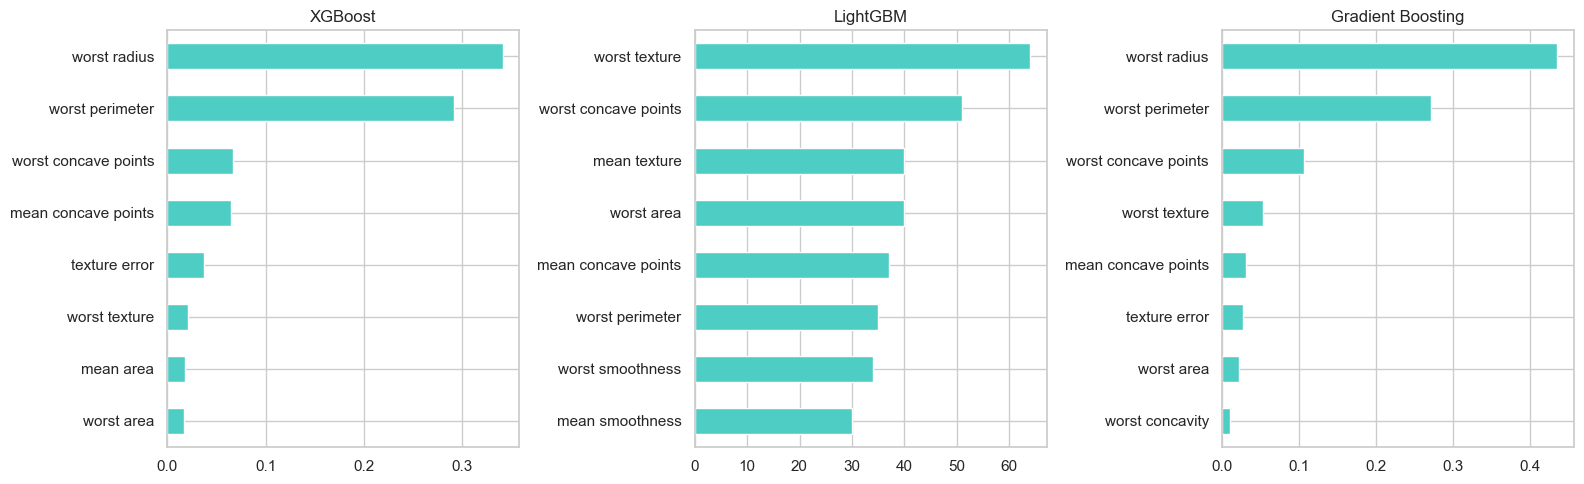

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
importances = {
    "XGBoost": pd.Series(xgb_model.feature_importances_, index=cancer.feature_names),
    "LightGBM": pd.Series(lgb_model.feature_importances_, index=cancer.feature_names),
    "Gradient Boosting": pd.Series(gb_final.feature_importances_ if hasattr(gb_final, "feature_importances_") else gb_model.feature_importances_, index=cancer.feature_names),
}
for ax, (name, imp) in zip(axes, importances.items()):
    imp.sort_values(ascending=False).head(8).plot(kind="barh", ax=ax, color="#4ecdc4")
    ax.set_title(name)
    ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 14. Early Stopping — Preventing Overfitting Automatically

Rather than guessing the right `n_estimators`, **early stopping** monitors validation performance during training and halts once it stops improving — the boosting equivalent of the Decision Tree's pruning parameters, but applied dynamically during fit rather than fixed upfront.


In [30]:
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
early_stop_model = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.1, max_depth=3, random_state=42,
    eval_metric="logloss", early_stopping_rounds=10
)
early_stop_model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [31]:
print(f"Requested up to 1000 trees; stopped early at: {early_stop_model.best_iteration + 1} trees")
print(f"Test accuracy: {accuracy_score(y_test, early_stop_model.predict(X_test)):.4f}")


Requested up to 1000 trees; stopped early at: 126 trees
Test accuracy: 0.9561


## 15. Final Evaluation — Best Boosting Model on Breast Cancer


In [32]:
best_boosting_preds = xgb_model.predict(X_test)
print(classification_report(y_test, best_boosting_preds, target_names=cancer.target_names))


              precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



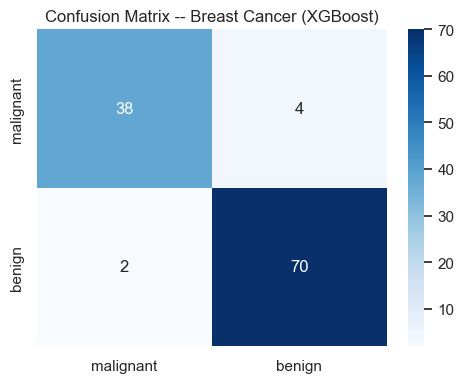

In [33]:
cm = confusion_matrix(y_test, best_boosting_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
ax.set_title("Confusion Matrix -- Breast Cancer (XGBoost)")
plt.tight_layout()
plt.show()


## 16. The Complete Classification Category — Final Comparison

Every algorithm from this entire category, head-to-head on the same Breast Cancer split — the payoff for building all eight notebooks the same rigorous way.


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler


In [35]:
X_train_s = StandardScaler().fit_transform(X_train)
X_test_s = StandardScaler().fit(X_train).transform(X_test)


In [36]:
all_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", C=10, gamma=0.01),
    "LDA": LinearDiscriminantAnalysis(),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, eval_metric="logloss"),
}


In [37]:
final_results = []
for name, model in all_models.items():
    model.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_s))
    final_results.append({"Algorithm": name, "Test Accuracy": round(acc, 4)})
pd.DataFrame(final_results).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)


,Algorithm,Test Accuracy
0,Logistic Regression,0.9825
1,SVM (RBF),0.9825
2,Random Forest,0.9561
3,KNN,0.9561
4,LDA,0.9561
5,XGBoost,0.9474
6,Decision Tree,0.9386
7,Naive Bayes,0.9298


## ✅ Key Takeaways

- Boosting trains trees **sequentially**, each one correcting the ensemble's current mistakes — the opposite strategy from Random Forest's independent, parallel trees, and it primarily reduces **bias** rather than variance.
- **AdaBoost** reweights misclassified *samples*; **Gradient Boosting** fits new trees to the *residual/gradient* of the loss — two different mechanisms for the same sequential-correction idea.
- `learning_rate` (shrinkage) and `n_estimators` trade off directly — smaller learning rates need more trees but generalize better, echoing the Math Refresher's gradient descent step-size intuition.
- **XGBoost** adds explicit regularization and second-order optimization; **LightGBM** grows leaf-wise for speed on large data; **CatBoost** adds ordered boosting and native categorical handling — three different engineering answers to the same core gradient boosting idea, not three unrelated algorithms.
- **Early stopping** is the boosting-native way to prevent overfitting, monitoring validation performance live instead of fixing `n_estimators` upfront.
- No algorithm in this entire category was strictly best on every measure (section 16) — the right choice depends on data size, interpretability needs, and compute budget, which is precisely why this category built all eight from the same rigorous standard.

**Classification category complete (8/8).** Next up: [Ensemble Techniques](../../Ensemble_Techniques/) — bagging and voting/stacking, generalized beyond trees to any base model.
